# SimilarWeb Clickstream Data — Detailed Description

This notebook profiles **`data/similarweb_clickstream_data/`** — the **behavioral / attribution**
view of SimilarWeb AI-recommendation activity. Where the *transformed* dataset describes *what the AI
recommended and how it maps to a purchase funnel*, this dataset captures **what users actually did
next**: which surfaced links they clicked, where they browsed, and whether it led to a purchase.

Six Parquet tables:

```mermaid
erDiagram
    simweb_input_file        ||--|| fact_ai_search_turn : "message_id (raw → transformed)"
    fact_ai_search_turn      ||--o{ fact_ai_recommendation : "message_id"
    fact_ai_recommendation   ||--o{ fact_ai_concept : "recommendation_id = fact_id"
    fact_ai_search_turn      ||--o{ fact_ai_click_through : "message_id"
    dim_digital_site         ||--o{ fact_ai_click_through : "digital_site_id"
```

- **`simweb_input_file`** — the raw, pre-transformation export (question/answer, language, feedback, the raw `next_10_urls` browsing trail, model variant).
- **`fact_ai_search_turn`** — the user↔LLM turns (shared schema with the transformed dataset).
- **`fact_ai_recommendation`** / **`fact_ai_concept`** — entities the AI named and their standardised attributes (shared schema).
- **`fact_ai_click_through`** — ⭐ the clickstream: every surfaced link, whether it was AI-recommended, whether it was visited, and whether it led to a purchase.
- **`dim_digital_site`** — a catalog of every URL/site (page type, seller type, category, retailer, SKUs).

> **The headline:** this dataset answers *"did the AI recommendation actually drive a click and a
> purchase?"* — a question the transformed dataset cannot. See **§10** for the full comparison.


## Setup — load every table

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

CLICK = Path("data/similarweb_clickstream_data")
TRANS = Path("data/similarweb_transformed_data")   # for the comparison in section 10

TABLES = {p.stem: pd.read_parquet(p) for p in sorted(CLICK.glob("*.parquet"))}
search_turn    = TABLES["fact_ai_search_turn"]
recommendation = TABLES["fact_ai_recommendation"]
concept        = TABLES["fact_ai_concept"]
click_through  = TABLES["fact_ai_click_through"]
digital_site   = TABLES["dim_digital_site"]
input_file     = TABLES["simweb_input_file"]

print(f"loaded {len(TABLES)} tables:")
for name, df in TABLES.items():
    print(f"  {name:26} {df.shape[0]:>9,} rows x {df.shape[1]} cols")

# many object columns store the literal string 'None'/'nan' instead of NaN — treat as missing
def as_missing(s):
    return s.replace({"None": np.nan, "nan": np.nan, "": np.nan})

loaded 6 tables:
  dim_digital_site             265,305 rows x 16 cols
  fact_ai_click_through        480,668 rows x 17 cols
  fact_ai_concept              292,485 rows x 4 cols
  fact_ai_recommendation        44,498 rows x 6 cols
  fact_ai_search_turn           53,650 rows x 8 cols
  simweb_input_file             53,650 rows x 22 cols


## 1 · Schema at a glance
| Table | Grain (one row per…) | Key | New vs transformed? |
|-------|----------------------|-----|---------------------|
| `simweb_input_file` | raw **turn** (pre-transform) | `message_id` | ✅ new |
| `fact_ai_search_turn` | user↔LLM **turn** | `message_id` (PK) | shared schema |
| `fact_ai_recommendation` | **entity** named in a turn | `recommendation_id` (PK) | shared schema |
| `fact_ai_concept` | one **attribute** of an entity | (`fact_id`,`concept_name`,`concept_value`) | shared schema |
| `fact_ai_click_through` | **surfaced link / click event** | `click_id` (PK) | ✅ new ⭐ |
| `dim_digital_site` | a **URL / site** | `digital_site_id` (PK) | ✅ new |

In [2]:
def profile(df, name):
    info = pd.DataFrame({
        "dtype":  df.dtypes.astype(str),
        "nulls":  df.isna().sum(),
        "null_%": (df.isna().mean() * 100).round(1),
        "n_unique": [df[c].nunique() if df[c].map(lambda v: not isinstance(v, (list, np.ndarray))).all()
                     else "list/array" for c in df.columns],
    })
    print(f"### {name}  —  {len(df):,} rows x {df.shape[1]} cols")
    print(info.to_string()); print()

for name, df in TABLES.items():
    profile(df, name)

### dim_digital_site  —  265,305 rows x 16 cols
                        dtype   nulls  null_%  n_unique
digital_site_id         int64       0     0.0    265305
url                       str       0     0.0    265305
domain                    str       0     0.0     24194
subdomain                 str       0     0.0      4834
path                      str       0     0.0    159448
query                     str  121319    45.7    123219
page_type                 str       0     0.0         8
seller_type               str       0     0.0         3
category                  str   17086     6.4        26
sub_category              str   43732    16.5       182
retailer_category         str  208822    78.7         4
specialist_category       str  245588    92.6        13
retailer_brand            str  260178    98.1       162
marketplace_type          str  252765    95.3         2
search_terms              str  217072    81.8     33831
extracted_product_skus    str  248884    93.8     12352


## 2 · `fact_ai_click_through` — the clickstream (⭐ the new core)
Every link **surfaced** to the user, tagged with whether it was an **AI recommendation**
(`was_recommended`), whether the user **visited** it (`was_visited`), and whether the visit
**resulted in a purchase** (`resulted_in_purchase`). `attribution_type` (`direct` / `indirect` /
`none`) links a purchase back to the AI recommendation. `recommendation_id` is **always null** here —
clicks join to the *turn* (`message_id`), not to a specific recommended entity.

In [3]:
ct = click_through
print(f"click events: {len(ct):,}  across {ct['message_id'].nunique():,} turns / {ct['conversation_id'].nunique():,} sessions")
print(f"unique destination sites: {ct['digital_site_id'].nunique():,}\n")

print("attribution_type (purchase attributed to the AI recommendation):")
print(ct["attribution_type"].value_counts().to_string())

print("\n--- the surfaced-link funnel ---")
print(f"was_recommended (link came from the AI): {ct['was_recommended'].mean():.1%}")
print(f"was_visited (user actually went there):  {ct['was_visited'].mean():.1%}")
print(f"resulted_in_purchase:                    {ct['resulted_in_purchase'].mean():.2%}")
print(f"\nvisit rate | AI-recommended link: {ct.loc[ct['was_recommended'], 'was_visited'].mean():.1%}")
print(f"visit rate | organic link:        {ct.loc[~ct['was_recommended'], 'was_visited'].mean():.1%}")
print(f"purchase rate | visited:          {ct.loc[ct['was_visited'], 'resulted_in_purchase'].mean():.2%}")
print("\ndate coverage (date_id):", ct["date_id"].min(), "->", ct["date_id"].max(), f"({ct['date_id'].nunique()} days)")

click events: 480,668  across 53,650 turns / 24,924 sessions
unique destination sites: 265,305

attribution_type (purchase attributed to the AI recommendation):
attribution_type
none        413794
indirect     65716
direct        1158

--- the surfaced-link funnel ---
was_recommended (link came from the AI): 12.5%
was_visited (user actually went there):  87.7%
resulted_in_purchase:                    10.25%

visit rate | AI-recommended link: 2.0%
visit rate | organic link:        100.0%
purchase rate | visited:          9.35%

date coverage (date_id): 20260101 -> 20260201 (32 days)


In [4]:
print("Top destination domains (all surfaced links):")
print(ct["destination_domain"].pipe(as_missing).value_counts().head(12).to_string())
print("\nTop domains that RESULTED IN A PURCHASE:")
print(ct.loc[ct["resulted_in_purchase"], "destination_domain"].value_counts().head(10).to_string())

Top destination domains (all surfaced links):
destination_domain
google.com       79794
chatgpt.com      39567
youtube.com      39054
amazon.com       38918
shopify.com      20029
facebook.com     10252
instagram.com    10095
tiktok.com        9935
reddit.com        7052
pinterest.com     6497
walmart.com       5550
roblox.com        4116

Top domains that RESULTED IN A PURCHASE:
destination_domain
amazon.com      17098
google.com       3452
chatgpt.com      2118
walmart.com      1468
youtube.com      1078
shopify.com      1021
target.com        986
facebook.com      730
sephora.com       712
reddit.com        587


## 3 · `dim_digital_site` — the destination catalog
One row per URL the clickstream references. `page_type` classifies each URL's role in a shopping
journey (`pdp` = product detail page, `checkout`, `marketplace`, `search`, …); `seller_type`
distinguishes first-party (`1p`) vs third-party (`3p`); plus `category` / `retailer_brand` /
`extracted_product_skus`. Many optional fields store the literal string `'None'` rather than NaN.

In [5]:
ds = digital_site
print(f"sites: {len(ds):,} | unique domains: {ds['domain'].pipe(as_missing).nunique():,}\n")
print("page_type:"); print(ds["page_type"].value_counts().to_string())
print("\nseller_type:"); print(ds["seller_type"].value_counts().to_string())
print("\nTop categories (non-null):")
print(ds["category"].pipe(as_missing).value_counts().head(10).to_string())
print("\nfields present (non-'None') per column:")
cov = {c: ds[c].pipe(as_missing).notna().mean() for c in
       ["category", "sub_category", "retailer_brand", "search_terms", "extracted_product_skus"]}
print(pd.Series(cov).mul(100).round(1).astype(str).add(" %").to_string())

sites: 265,305 | unique domains: 24,193

page_type:
page_type
other            158928
search            46043
pdp               43155
marketplace        6754
category           6447
checkout           2655
retailer_site      1120
brand_site          203

seller_type:
seller_type
unknown    252765
1p           7675
3p           4865

Top categories (non-null):
category
Computers_Electronics_and_Technology    85537
E-commerce_and_Shopping                 34110
Lifestyle                               30925
Arts_and_Entertainment                  23542
AI_Chatbots_and_Tools                   21272
Business_and_Consumer_Services          18186
Health                                   7865
Science_and_Education                    6479
Games                                    3462
News_and_Media                           3258

fields present (non-'None') per column:
category                  93.6 %
sub_category              83.5 %
retailer_brand             1.9 %
search_terms              18.

## 4 · `simweb_input_file` — the raw pre-transformation input
The source export the whole pipeline is built from — one row per turn, identical `message_id` set to
`fact_ai_search_turn`. It carries fields the transformed tables drop: the **model variant**
(`sub_type`), **language** of question/answer (multilingual), user **feedback**, the chain-of-thought
prompt, and the raw browsing arrays **`next_10_urls`** (the clickstream before it was modelled),
`a_links_source`, and `ai_click`.

In [6]:
inp = input_file
print("service / model (sub_type):"); print(inp["sub_type"].value_counts().head(6).to_string())
print("\nquestion language (multilingual — transformed data is English-centric):")
print(inp["language_q"].value_counts().head(8).to_string())
print(f"\ntotal distinct languages: {inp['language_q'].nunique()}")
print("\nplatform:", inp["platform"].unique().tolist(), "| country:", inp["country_name"].unique().tolist())
print("feedback:", inp["feedback"].value_counts().to_dict())

# next_10_urls is the raw clickstream trail per turn (list of {request_time, requested_site})
ex = inp.loc[inp["next_10_urls"].map(lambda v: isinstance(v, (list, np.ndarray)) and len(v) > 0), "next_10_urls"].iloc[0]
print("\nexample next_10_urls[0] (raw browsing trail entry):")
print(" ", dict(ex[0]) if len(ex) else ex)

service / model (sub_type):
sub_type
gpt-5.2             39514
gpt-5-mini           7549
gpt-5.2-thinking     2480
gpt-5                1771
gpt-5.2-instant      1167
gpt-4o                655

question language (multilingual — transformed data is English-centric):
language_q
en       42401
zh-cn     2285
es         946
ko         901
fr         784
it         467
pt         441
ru         426

total distinct languages: 47

platform: ['desktop'] | country: ['United States']
feedback: {'Unknown': 53600, 'Up': 45, 'Down': 5}

example next_10_urls[0] (raw browsing trail entry):
  {'request_time': '1769448157367', 'requested_site': 'https://admin.shopify.com/store/masuta-kitchen'}


## 5 · Shared tables — search turns, recommendations, concepts
`fact_ai_search_turn`, `fact_ai_recommendation`, and `fact_ai_concept` share their schema with the
transformed dataset. Two things differ: this pull is **larger** and the concept taxonomy has **10**
attribute types (adds `CATEGORY` + `SUBCATEGORY`). ⚠️ `question_ts` here is in **microseconds**
(16-digit) vs **milliseconds** in the transformed data.

In [7]:
st = search_turn
st_ts = pd.to_datetime(st["question_ts"], unit="us")   # microseconds here (vs ms in transformed!)
print(f"turns: {len(st):,} | sessions: {st['session_id'].nunique():,} | users: {st['user_id'].nunique():,}")
print(f"time span: {st_ts.min()} -> {st_ts.max()}")
print(f"\nrecommendations: {len(recommendation):,} | mention_type: {recommendation['mention_type'].value_counts().to_dict()}")
print(f"rank max: {recommendation['rank'].max()}")
print(f"\nconcept attribute types ({concept['concept_name'].nunique()}):")
print(concept["concept_name"].value_counts().to_string())

turns: 53,650 | sessions: 24,924 | users: 14,173
time span: 2026-01-01 05:00:44 -> 2026-02-01 04:59:42

recommendations: 44,498 | mention_type: {'recommended': 37986, 'requested': 6512}
rank max: 85

concept attribute types (10):
concept_name
SUBCATEGORY                                   44498
CATEGORY                                      44498
APPLICATION_AREA                              40698
FORM                                          40496
BRAND                                         28502
FORMULATION_DESCRIPTORCLAIM                   24743
SUB_BRAND                                     22404
STRATEGIC_INGREDIENT_PRESENCEABSENCE_CLAIM    18917
TARGET_SKIN_CONCERNCONDITION                  16781
TARGET_SKIN_AUDIENCE                          10948


## 6 · Join integrity
Every foreign key, verified directly (1.0 = every child finds its parent).

In [8]:
checks = {
    "click_through.message_id -> search_turn.message_id":
        click_through["message_id"].isin(set(search_turn["message_id"])).mean(),
    "click_through.digital_site_id -> dim_digital_site.digital_site_id":
        click_through["digital_site_id"].isin(set(digital_site["digital_site_id"])).mean(),
    "click_through.recommendation_id populated":
        click_through["recommendation_id"].notna().mean(),
    "concept.fact_id -> recommendation.recommendation_id":
        concept["fact_id"].isin(set(recommendation["recommendation_id"])).mean(),
    "recommendation.message_id -> search_turn.message_id":
        recommendation["message_id"].isin(set(search_turn["message_id"])).mean(),
    "input_file.message_id == search_turn.message_id (same set)":
        float(set(input_file["message_id"]) == set(search_turn["message_id"])),
}
display(pd.Series(checks).round(4).to_frame("coverage"))

,coverage
click_through.message_id -> search_turn.message_id,1.0000
click_through.digital_site_id -> dim_digital_site.digital_site_id,1.0000
click_through.recommendation_id populated,0.0000
concept.fact_id -> recommendation.recommendation_id,1.0000
recommendation.message_id -> search_turn.message_id,0.9925
input_file.message_id == search_turn.message_id (same set),1.0000


## 7 · End-to-end example — one turn and everything the user did next
A single `message_id` pulled through the model: the turn text → what the AI recommended →
which links were surfaced, visited, and whether any purchase followed.

In [9]:
# pick a turn that has both recommendations and a visited click-through
visited_msgs = set(click_through.loc[click_through["was_visited"], "message_id"])
cand = recommendation[recommendation["message_id"].isin(visited_msgs)]["message_id"]
mid = cand.value_counts().index[0]

turn = search_turn[search_turn.message_id == mid].iloc[0]
print("MESSAGE_ID:", mid, "| session:", turn["session_id"])
print("PROMPT  :", turn["prompt_text"][:200])
print("RESPONSE:", turn["response_text"][:200])

recs = recommendation[recommendation.message_id == mid].sort_values("rank")
print(f"\nAI RECOMMENDATIONS ({len(recs)}):")
for _, r in recs.head(4).iterrows():
    print(f"  #{r['rank']} [{r['mention_type']}] {r['entity_context'][:80]}")

clk = click_through[click_through.message_id == mid].merge(
    digital_site[["digital_site_id", "page_type", "seller_type"]], on="digital_site_id", how="left")
print(f"\nCLICK-THROUGHS ({len(clk)}):")
for _, c in clk.head(8).iterrows():
    flags = f"rec={c['was_recommended']:d} visited={c['was_visited']:d} purchase={c['resulted_in_purchase']:d}"
    print(f"  [{c['page_type']:>11}/{c['seller_type']:<3}] {flags}  {str(c['destination_domain'])[:40]}")

MESSAGE_ID: 81d894594bf0449c27f3419de92874ae | session: 79bdba9d-edb9-e603-07e0-821c12a587be
PROMPT  : Got it 👍 thanks for clarifying — you want editing + corrections + professional guidance, not a new list.
I’ll go phase by phase, tell you what’s correct, what to adjust, and what I’d change if this we
RESPONSE: Alright 👍 I’m keeping everything from the last answer as-is.
Now I’ll add on what you asked for, without rewriting your routine.
You asked for:


US retail only


Large, mainstream platforms (Amazon, 

AI RECOMMENDATIONS (85):
  #1 [recommended] CeraVe Hydrating Facial Cleanser is a gentle water-based facial cleanser for dai
  #2 [recommended] La Roche-Posay Toleriane Hydrating Gentle Cleanser is a gentle water-based facia
  #3 [recommended] Vanicream Gentle Facial Cleanser is a gentle water-based facial cleanser for dai
  #4 [recommended] Neutrogena Ultra Gentle Cleanser is a gentle water-based facial cleanser for dai

CLICK-THROUGHS (9):
  [      other/unknown] rec=0 visited=

## 8 · Visual overview

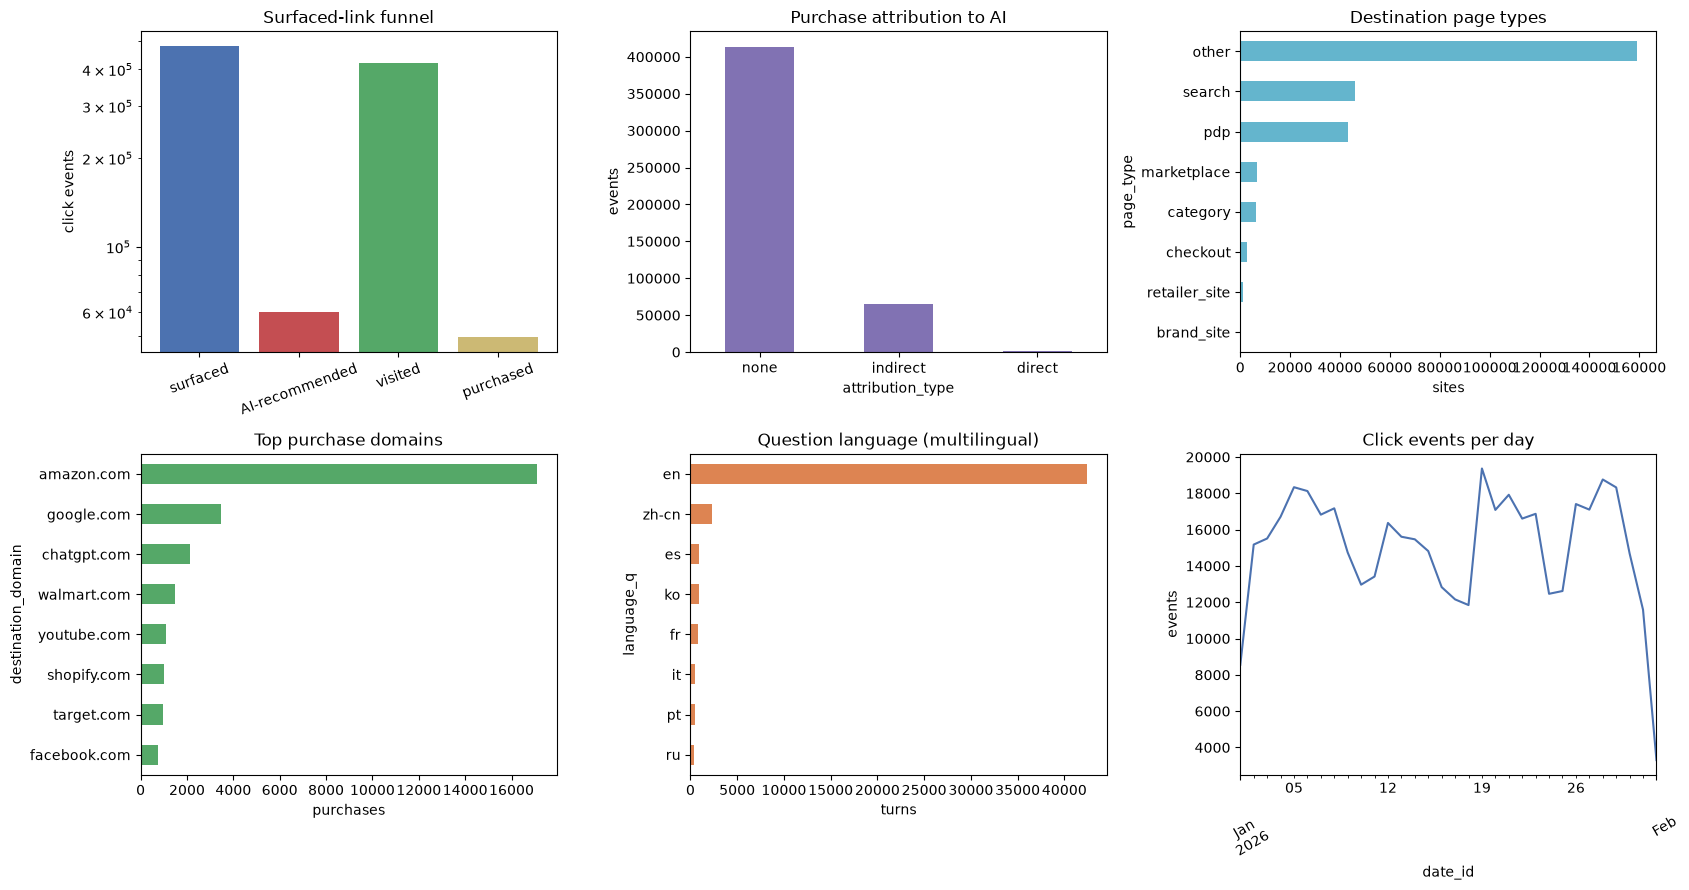

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(17, 9))

# surfaced-link funnel
funnel = pd.Series({
    "surfaced":      len(click_through),
    "AI-recommended": int(click_through["was_recommended"].sum()),
    "visited":       int(click_through["was_visited"].sum()),
    "purchased":     int(click_through["resulted_in_purchase"].sum()),
})
ax[0, 0].bar(funnel.index, funnel.values, color=["#4C72B0", "#C44E52", "#55A868", "#CCB974"])
ax[0, 0].set(title="Surfaced-link funnel", ylabel="click events"); ax[0, 0].set_yscale("log")
ax[0, 0].tick_params(axis="x", rotation=20)

# attribution type
click_through["attribution_type"].value_counts().plot.bar(ax=ax[0, 1], color="#8172B3")
ax[0, 1].set(title="Purchase attribution to AI", ylabel="events"); ax[0, 1].tick_params(axis="x", rotation=0)

# page_type of destinations
digital_site["page_type"].value_counts().iloc[::-1].plot.barh(ax=ax[0, 2], color="#64B5CD")
ax[0, 2].set(title="Destination page types", xlabel="sites")

# top purchase domains
click_through.loc[click_through["resulted_in_purchase"], "destination_domain"].value_counts().head(8).iloc[::-1].plot.barh(
    ax=ax[1, 0], color="#55A868")
ax[1, 0].set(title="Top purchase domains", xlabel="purchases")

# languages
input_file["language_q"].value_counts().head(8).iloc[::-1].plot.barh(ax=ax[1, 1], color="#DD8452")
ax[1, 1].set(title="Question language (multilingual)", xlabel="turns")

# clicks per day
cd = pd.to_datetime(click_through["date_id"].astype(str), format="%Y%m%d")
cd.value_counts().sort_index().plot(ax=ax[1, 2], color="#4C72B0")
ax[1, 2].set(title="Click events per day", ylabel="events"); ax[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

## 9 · Data-quality notes
- **`click_through.recommendation_id` is 100% null** — clicks attribute to the **turn** (`message_id`),
  not to a specific recommended entity. Use `message_id` + `was_recommended` for AI attribution.
- **`question_ts` is microseconds** (16-digit) here, vs **milliseconds** in the transformed data —
  convert with `unit="us"`, not `unit="ms"`.
- Many optional string columns store the literal **`'None'`** instead of NaN (`query`, `category`,
  `retailer_brand`, …) — the `as_missing()` helper normalises them.
- `input_file` is **multilingual** (47 question languages) and records the **model variant**
  (`gpt-5.2`, `gpt-5-mini`, `gpt-5.2-thinking`, …); the transformed dataset is English-only and drops the model.

## 10 · Main differences vs `similarweb_transformed_data`

Both datasets share `fact_ai_search_turn`, `fact_ai_recommendation`, and `fact_ai_concept` (same
schema, **different sample** — only ~9% of turns overlap). Everything else diverges:

| | `similarweb_transformed_data` | `similarweb_clickstream_data` |
|---|---|---|
| **Purpose** | *Analytical*: what the AI recommended + how it maps to a **funnel stage** and **topics** | *Behavioral*: what the user **clicked / visited / purchased** after the AI answer |
| **Tables** | 7 | 6 |
| **Unique tables** | `dim_ai_funnel` + `fact_ai_funnel`, `dim_ai_topic` + `fact_ai_topic` | `fact_ai_click_through`, `dim_digital_site`, `simweb_input_file` |
| **Purchase-funnel stage** | ✅ (Awareness→Post-Purchase) | ❌ |
| **Topic model** | ✅ (34 topics, q/a/session) | ❌ |
| **Click / visit / purchase** | ❌ | ✅ `fact_ai_click_through` |
| **Destination-site catalog** | ❌ | ✅ `dim_digital_site` (page_type, seller_type, SKUs) |
| **Raw pre-transform input** | ❌ | ✅ `simweb_input_file` (multilingual, `next_10_urls`, feedback, model) |
| **Concept attributes** | 8 types | 10 types (adds `CATEGORY`, `SUBCATEGORY`) |
| **Scale** | 39,541 turns / 4,622 sessions | 53,650 turns / 24,924 sessions |
| **Language** | English-centric | multilingual (47 languages) |
| **Model captured** | — | `gpt-5.2` family (in the raw input) |
| **`question_ts` unit** | milliseconds (13-digit) | microseconds (16-digit) |
| **`rank` max** | 44 | 85 |

**In one line:** the *transformed* dataset tells you **what the AI said and where it sits in the
buyer journey**; the *clickstream* dataset tells you **whether anyone acted on it** — the missing
attribution half (surfaced → visited → purchased) plus the raw browsing trail and destination sites,
at the cost of the funnel/topic classifications.

In [11]:
# quick programmatic confirmation of the table-set difference
click_tabs = {p.stem for p in CLICK.glob("*.parquet")}
trans_tabs = {p.stem for p in TRANS.glob("*.parquet")} if TRANS.exists() else set()
print("shared tables      :", sorted(click_tabs & trans_tabs))
print("only in clickstream:", sorted(click_tabs - trans_tabs))
print("only in transformed:", sorted(trans_tabs - click_tabs))

shared tables      : ['fact_ai_concept', 'fact_ai_recommendation', 'fact_ai_search_turn']
only in clickstream: ['dim_digital_site', 'fact_ai_click_through', 'simweb_input_file']
only in transformed: ['dim_ai_funnel', 'dim_ai_topic', 'fact_ai_funnel', 'fact_ai_topic']


In [12]:
click_through

,click_id,message_id,recommendation_id,conversation_id,attribution_type,was_recommended,was_visited,digital_site_id,surfaced_url,destination_domain,link_position,clickstream_position,resulted_in_purchase,purchase_product_sku,purchase_digital_site_id,purchase_same_domain_as_link,date_id
0,1,82108919bc583b142347df8032038d14,None,43349b70-3a53-7aee-f956-ea2002e86c7f,none,True,False,141572,https://www.columbiadoctors.org/news/do-air-fresheners-impact-our-health,columbiadoctors.org,0.0,NaN,False,NaN,NaN,False,20260129
1,2,cfb498c3c124dbed460cbea0281be621,None,a5d94b13-9ea8-0ea6-c277-aa7e7c1f98c9,none,True,False,832,https://a-z-animals.com/reviews/best-pet-wipes,a-z-animals.com,0.0,NaN,False,NaN,NaN,False,20260107
2,3,cfb498c3c124dbed460cbea0281be621,None,a5d94b13-9ea8-0ea6-c277-aa7e7c1f98c9,none,True,False,226596,https://www.thedodo.com/paw-of-approval/handson-grooming-gloves-review,thedodo.com,1.0,NaN,False,NaN,NaN,False,20260107
3,4,399d49bae7f2d5c7bc9f80c08f63c886,None,da3da1ba-e8cf-1e35-dcec-b4969e22d673,none,True,False,62597,https://ecocult.com/safe-non-toxic-eco-laundry-detergent,ecocult.com,0.0,NaN,False,NaN,NaN,False,20260110
4,5,399d49bae7f2d5c7bc9f80c08f63c886,None,da3da1ba-e8cf-1e35-dcec-b4969e22d673,none,True,False,78051,https://lifed.com/5-best-laundry-detergents-to-avoid-toxic-ingredients,lifed.com,1.0,NaN,False,NaN,NaN,False,20260110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480663,480664,f0766c184eaf3ffe7438bfaca0517e65,None,19f4730b-882b-12b9-3f1f-f58ed1d9d647,none,False,True,42088,https://chatgpt.com/c/6972a624-b5b4-832c-8255-c2a83fb06146,chatgpt.com,NaN,5.0,False,NaN,NaN,False,20260122
480664,480665,f0766c184eaf3ffe7438bfaca0517e65,None,19f4730b-882b-12b9-3f1f-f58ed1d9d647,none,False,True,252117,https://www.youtube.com/shorts/wa8gOllDLxI,youtube.com,NaN,6.0,False,NaN,NaN,False,20260122
480665,480666,f0766c184eaf3ffe7438bfaca0517e65,None,19f4730b-882b-12b9-3f1f-f58ed1d9d647,none,False,True,249420,https://www.youtube.com/shorts/MtmGEC5jfho,youtube.com,NaN,7.0,False,NaN,NaN,False,20260122
480666,480667,f0766c184eaf3ffe7438bfaca0517e65,None,19f4730b-882b-12b9-3f1f-f58ed1d9d647,none,False,True,251991,https://www.youtube.com/shorts/uaSS7z-O_ig,youtube.com,NaN,8.0,False,NaN,NaN,False,20260122
